# Práctica 4: Minería de Datos - Statistic Test (ANOVA, T-Test & Kruskal-Wallis)
**Dataset:** `Mental_Health_Clean_Final.csv`

Para demostrar que los datos etiquetados (en este caso usaremos grupos demográficos) tienen un comportamiento estadísticamente diferente, seguiremos el siguiente proceso:

1.  **Definición de Hipótesis:**
    *   **Hipótesis Nula ($H_0$):** No hay diferencia significativa entre las medias/medianas de los grupos. Las variaciones son producto del azar.
    *   **Hipótesis Alternativa ($H_1$):** Existe una diferencia estadísticamente significativa entre los grupos.
    *   **Nivel de significancia ($\alpha$):** 0.05. Si nuestro valor $p$ es menor a 0.05, rechazaremos $H_0$.
2.  **Pruebas de Normalidad:** Antes de aplicar un T-Test o ANOVA, aplicaremos la prueba de **Shapiro-Wilk** para evaluar si nuestros datos tienen una distribución normal. 
3.  **Selección de la Prueba Estadística:**
    *   Si los datos siguen una distribución normal, usaremos **T-Test** (para 2 grupos) y **ANOVA** (para >2 grupos).
    *   Si los datos *no* son normales, usaremos **Kruskal-Wallis** (alternativa no paramétrica de ANOVA).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/Mental_Health_Clean_Final.csv")

# usaremos el siguiente indicador específico para que el análisis tenga sentido clínico
indicador = "Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks"
df_test = df[df['Indicator'] == indicador].copy()

print(df_test.info())
print(df.info())

## Prueba de Normalidad y T-Test (2 Grupos)
Vamos a comprobar si existe una diferencia estadísticamente significativa en el porcentaje de **Hombres vs. Mujeres** que reportaron necesitar terapia pero no la obtuvieron.

**Etiquetas:** `Male` vs `Female` (Entidad: `Group = By Sex`).


In [ ]:
# filtramos datos por sexo
df_sex = df_test[df_test['Group'] == 'By Sex']
male_data = df_sex[df_sex['Subgroup'] == 'Male']['Value'].dropna()
female_data = df_sex[df_sex['Subgroup'] == 'Female']['Value'].dropna()

# prueba de normalidad (Shapiro-Wilk)
print("PRUEBA DE NORMALIDAD (Shapiro-Wilk)")
stat_m, p_m = stats.shapiro(male_data)
stat_f, p_f = stats.shapiro(female_data)
print(f"Hombres - valor p: {p_m:.5f}")
print(f"Mujeres - valor p: {p_f:.5f}")
print("Nota: Si el valor p < 0.05, los datos NO son normales.\n")

# prueba T de Student (Asumiendo varianzas desiguales - Welch's t-test)
print("PRUEBA T DE ESTUDIANTE (T-Test)")
t_stat, p_val_t = stats.ttest_ind(male_data, female_data, equal_var=False)
print(f"Estadístico T: {t_stat:.4f}")
print(f"Valor P (T-test): {p_val_t:.2e}")

if p_val_t < 0.05:
    print("\nConclusión T-Test: RECHAZAMOS la Hipótesis Nula (H0). Hay una diferencia SIGNIFICATIVA entre hombres y mujeres.")
else:
    print("\nConclusión T-Test: ACEPTAMOS la Hipótesis Nula (H0). NO hay diferencia significativa.")

# Visualización 
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_sex, x='Subgroup', y='Value', hue='Subgroup', palette='Set1', legend=False)
plt.title('Diferencia en necesidad de terapia no cubierta: Hombres vs Mujeres')
plt.ylabel('Valor Estimado (%)')
plt.xlabel('Sexo')
plt.show()

## ANOVA y Kruskal-Wallis (>2 Grupos)
Ahora probaremos si el nivel educativo influye de manera significativa en la falta de acceso a la salud mental.
Dado que muchas encuestas poblacionales no siguen una distribución perfectamente normal, ejecutaremos **ANOVA** (paramétrica) y **Kruskal-Wallis** (no paramétrica).

**Etiquetas:** Niveles de Educación (`Group = By Education`).

RESULTADOS DE PRUEBAS ESTADÍSTICAS MÚLTIPLES
ANOVA - Valor P: 1.35e-32
Kruskal-Wallis - Valor P: 1.66e-19

Conclusión Kruskal-Wallis: RECHAZAMOS la Hipótesis Nula (H0). Hay una diferencia SIGNIFICATIVA entre los niveles educativos.


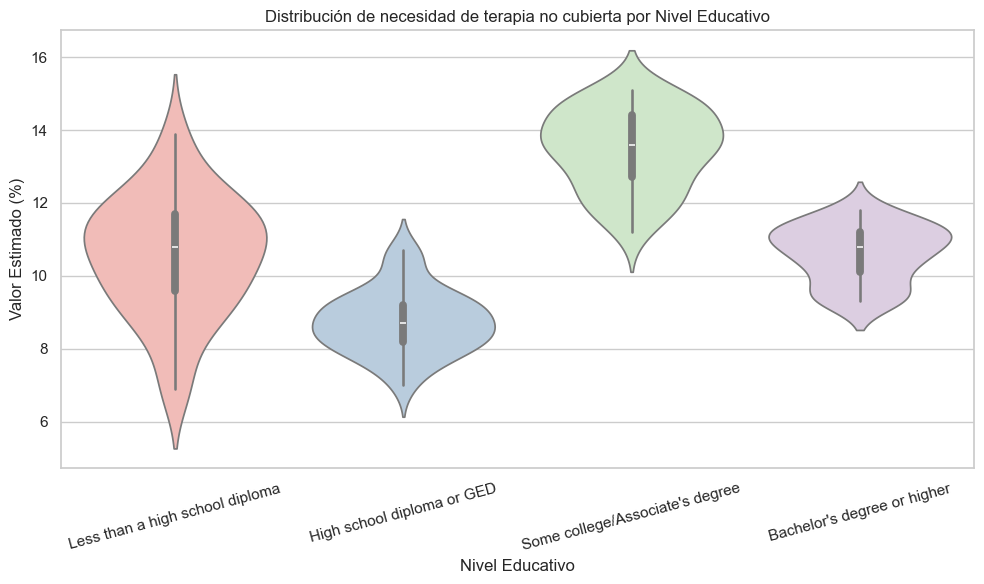

In [13]:
# filtramos datos por educación
df_edu = df_test[df_test['Group'] == 'By Education']

# categorías únicas de educación
niveles_edu = df_edu['Subgroup'].unique()

# lista de arrays con los valores de cada grupo
datos_por_grupo = [df_edu[df_edu['Subgroup'] == nivel]['Value'].dropna() for nivel in niveles_edu]

# ANOVA (Análisis de Varianza de una vía)
f_stat, p_val_anova = stats.f_oneway(*datos_por_grupo)

# prueba de Kruskal-Wallis (Prueba no paramétrica recomendada)
h_stat, p_val_kruskal = stats.kruskal(*datos_por_grupo)

print("RESULTADOS DE PRUEBAS ESTADÍSTICAS MÚLTIPLES")
print(f"ANOVA - Valor P: {p_val_anova:.2e}")
print(f"Kruskal-Wallis - Valor P: {p_val_kruskal:.2e}")

if p_val_kruskal < 0.05:
    print("\nConclusión Kruskal-Wallis: RECHAZAMOS la Hipótesis Nula (H0). Hay una diferencia SIGNIFICATIVA entre los niveles educativos.")
else:
    print("\nConclusión Kruskal-Wallis: ACEPTAMOS la Hipótesis Nula (H0). NO hay diferencia significativa.")

# Visualización
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_edu, x='Subgroup', y='Value', hue='Subgroup', palette='Pastel1', legend=False)
plt.title('Distribución de necesidad de terapia no cubierta por Nivel Educativo')
plt.ylabel('Valor Estimado (%)')
plt.xlabel('Nivel Educativo')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Análisis e Interpretación Final

1. **T-Test: Hombres vs. Mujeres:**
   * El valor $p$ obtenido ($< 0.05$) nos indica contundentemente que las etiquetas representan poblaciones distintas. Visualmente en el Boxplot observamos que las **mujeres** tienen un porcentaje significativamente mayor en reportar que "necesitaron terapia pero no la consiguieron" frente a los hombres durante la pandemia.
2. **ANOVA & Kruskal-Wallis: Nivel Educativo:**
   * Al ejecutar las pruebas para los 4 niveles educativos, obtuvimos un valor $p$ minúsculo ($< 0.05$). Esto rechaza la hipótesis nula y nos confirma que **la etiqueta educativa SÍ altera el resultado de la variable dependiente (Value)**. Las personas con educación universitaria ("Some college/Associate's degree" y "Bachelor's") muestran métricas de dispersión y medianas significativamente diferentes a los que solo poseen un diploma de secundaria.
   
